In [129]:
import sys, os
_src = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if _src not in sys.path: sys.path.insert(0, _src)



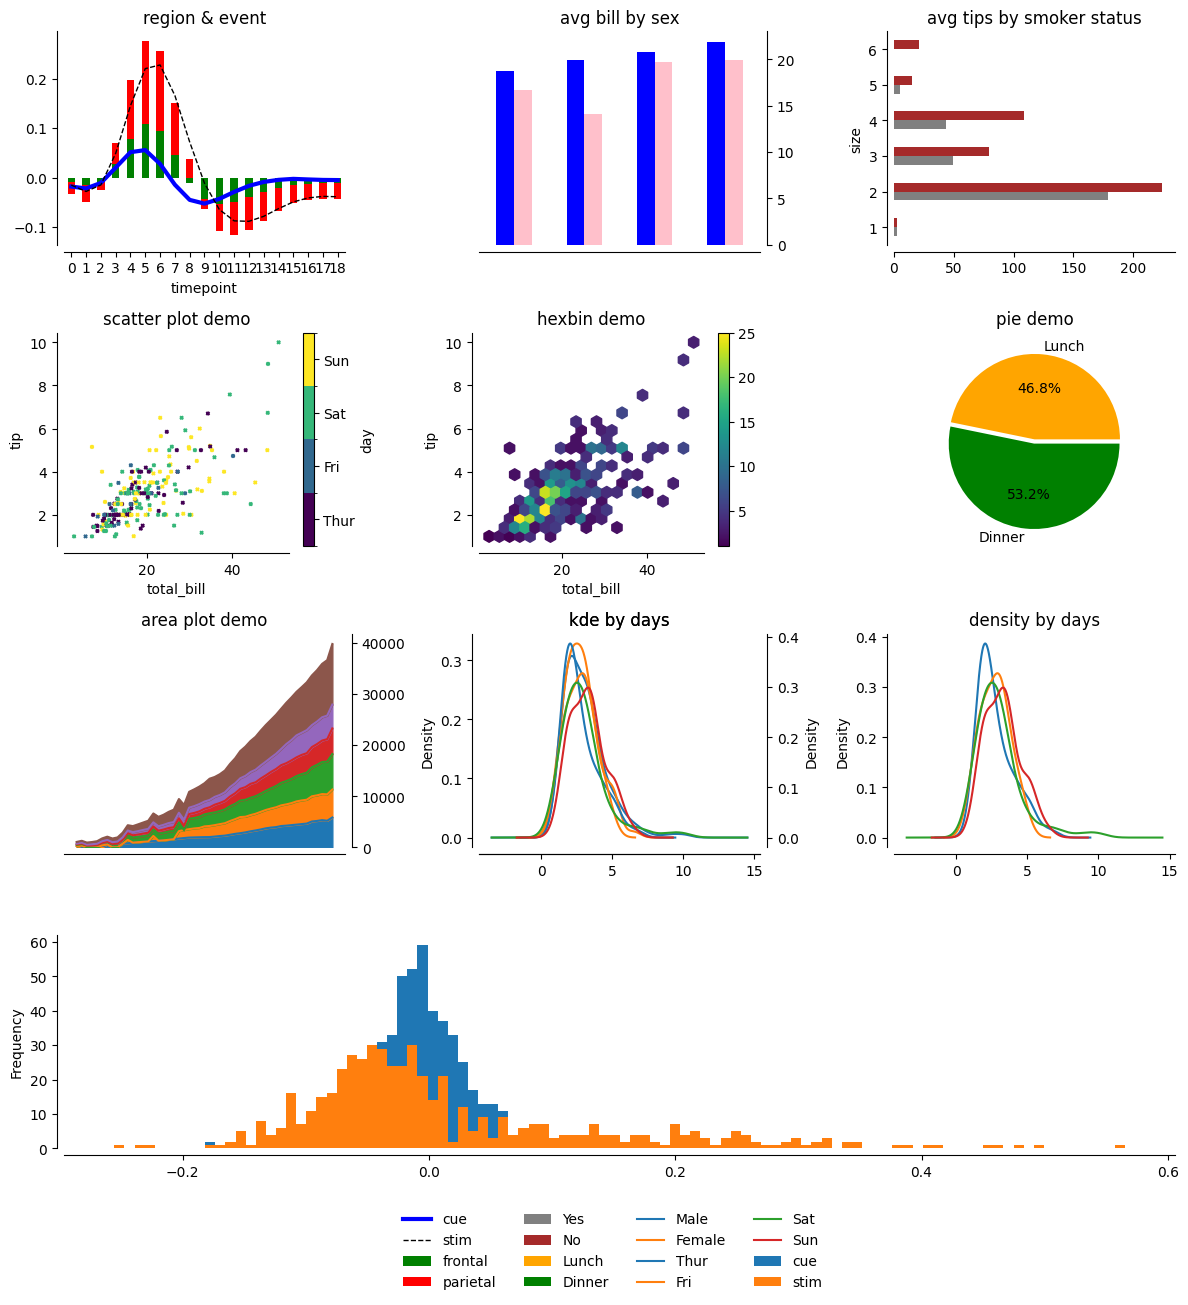

In [130]:
import numpy as np
import pandas as pd
import pytae as pt

fmri = pt.sample_data['fmri']
tips = pt.sample_data['tips']
healthexp = pt.sample_data['healthexp']


color={'cue': 'blue', 'stim': 'black', 'parietal': 'red',
       'frontal': 'green','Male':'blue','Female':'pink','Dinner':'green',
       'Lunch':'orange','Yes':'grey','No':'brown'}

style={'cue':'-','stim':'--'}
width={'cue':3,'stim':1}
marker = {'Male': 'o', 'Female': 'x'}
size={'Male': 10,'Female': 20}

mosaic = """
ABC
DEF
GHI
JJJ
"""
k = pt.Plotter(mosaic,figsize=(12, 12))

(k
.data(fmri)
.plot(x='timepoint', y='signal',by='event',aggfunc='mean',color=color,style=style,width=width,
      on='A',title='region & event',kind='line')
.plot(x='timepoint', y='signal',by='region',kind='bar',stacked=True,on='A',color=color,aggfunc='mean')
.data(tips)
.plot(x='day',y='total_bill',by='sex',aggfunc='mean',on='B^',kind='bar',color=color,
      title='avg bill by sex',legend=False)
.plot(x='size',y='tip',by='smoker',on='C',kind='barh',color=color,title='avg tips by smoker status')
.data(tips)
.plot(kind='scatter',x='total_bill',y='tip',on='D',marker='x',s=5,c='day',cmap='viridis',title='scatter plot demo')
.data(tips)
.plot(kind='hexbin',x='total_bill',y='tip',on='E',C='size',reduce_C_function=np.sum,cmap='viridis',gridsize=20,title='hexbin demo')
.data(tips)
.plot(kind='pie',y='tip',by='time',on='F',aggfunc='mean', autopct='%1.1f%%',colors=color,explode=(0,0.05),title='pie demo') #for pie matplotlib says colors and not color
.data(healthexp)
.plot(kind='area',x='Year',y='Spending_USD',aggfunc='mean',on='G^',legend=False, by='Country',title='area plot demo')
.data(tips)

.plot(kind='kde',on='H^',by='day',column='tip',title='kde by days')# ,secondary_y=True)
 .plot(kind='kde',column='tip',on='H', by='sex')
.plot(kind='density',on='I',by='day',column='tip',title='density by days' )
.data(fmri)
.plot(kind='hist',column='signal',by='event',on='J',bins=100)
.finalize(consolidate_legends=True,ncols=4, bbox_to_anchor=(0.7, -0.005)) 
# .finalize()

)



k.fig


In [131]:
k.plot_kwargs_store['A']['kind']

'bar'

   timepoint       cue      stim
0          0 -0.018151 -0.015172
1          1 -0.021955 -0.028049
2          2 -0.010830 -0.014916
3          3  0.020084  0.048808
4          4  0.051290  0.145098
5          5  0.055489  0.219962
6          6  0.027651  0.227380
7          7 -0.014388  0.165708
8          8 -0.045020  0.071860
9          9 -0.052590 -0.011492
10        10 -0.043028 -0.064342
11        11 -0.028997 -0.087392
12        12 -0.016701 -0.088351
13        13 -0.008810 -0.078254
14        14 -0.004595 -0.062726
15        15 -0.002604 -0.049156
16        16 -0.003766 -0.041063
17        17 -0.004742 -0.037994
18        18 -0.005045 -0.038690


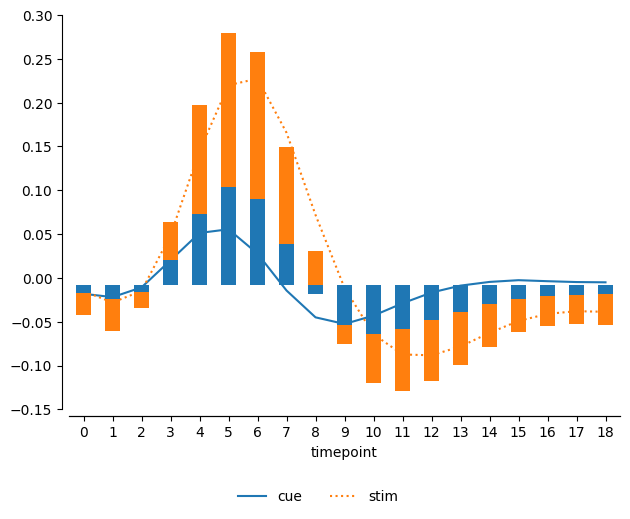

In [132]:
import numpy as np
import pandas as pd
import pytae as pt

fmri = pt.sample_data['fmri']

t = pt.Plotter() #if no mosaic is plotted it will automatically work on single subplot
(t
.data(fmri)
.plot(x='timepoint', y='signal',by='event',aggfunc='mean',kind='line',style={'cue':'-','stim':':'},ylim=(-0.15,0.3),print_data=1)
.plot(x='timepoint', y='signal',by='region',kind='bar',stacked=True,aggfunc='mean',on='A^',legend=False,print_data=0) 
 #if legend is set as False it will not be p[art of consolidated legend
.finalize(consolidate_legends=True, bbox_to_anchor=(0.65, -0.005), hide_secondary_y=True)
)
t.fig


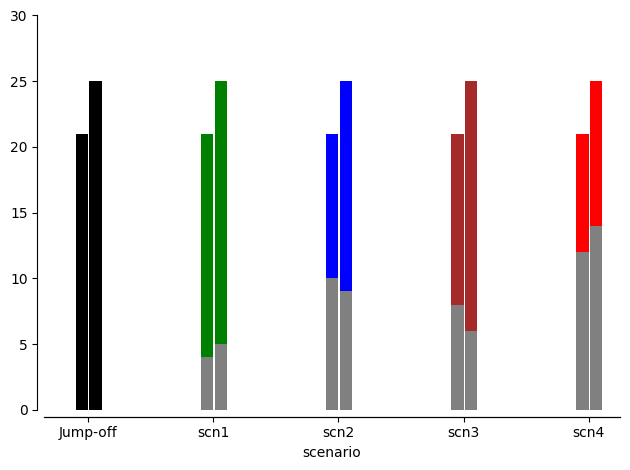

In [133]:

df = pd.DataFrame({
    'scenario': ['Jump-off', 'Jump-off', 'scn1', 'scn1', 'scn2', 'scn2', 'scn3', 'scn3', 'scn4', 'scn4'],
    'variable': ['depletion', 'surplus', 'depletion', 'surplus', 'depletion', 'surplus', 'depletion', 'surplus', 'depletion', 'surplus'],
    'last_cycle': [0, 25, 5, 20, 9, 16, 6, 19, 14, 11],
    'this_cycle': [0, 21, 4, 17, 10, 11, 8, 13, 12, 9]
})

variable_order = [ 'surplus','depletion']
df['scenario_variable'] = df['scenario'] + '_' + df['variable']
df['variable'] = pd.Categorical(df['variable'], categories=variable_order, ordered=True)


colors = {
    'Jump-off_surplus': 'black',    # Default for Jump-off
    'scn1_surplus': 'green',
    'scn2_surplus': 'blue',
    'scn3_surplus': 'brown',
    'scn4_surplus': 'red',
    'Jump-off_depletion': 'grey',
    'scn1_depletion': 'grey',
    'scn2_depletion': 'grey',
    'scn3_depletion': 'grey',
    'scn4_depletion': 'grey'
}
k = pt.Plotter()
(
    k
    .data(df)
    .plot(x='scenario', y='last_cycle', by='scenario_variable', aggfunc='sum', kind='bar', 
          width=0.1, position=-0.1, stacked=True, ylim=(0,30), color=colors, 
     hatch=None,legend=True)
    .plot(x='scenario', y='this_cycle', by='scenario_variable', aggfunc='sum', kind='bar',
          width=0.1, position=1, on='A^', stacked=True, hatch=None,)
    # .finalize(hide_secondary_y=True, legend_secondary=False)
# .finalize(consolidate_legends=True,ncols=2, bbox_to_anchor=(0.75, -0.005), hide_secondary_y=True) 
  .finalize(legend=False, hide_secondary_y=True)
)
## This is extreme  customization and hence not showing legends
k.fig

## Faceting, saving, introspecting supported kwargs, and opting out of styling

`Plotter.facet()` builds a small-multiples grid automatically (leftover grid cells are left blank, not turned into empty axes); `.save()` is a thin chainable wrapper around `fig.savefig()`; `Plotter.supported_kwargs(kind)` lists which kwargs a given kind ignores plus pytae's own control kwargs; `finalize(style=False)` skips pytae's opinionated spine/tick cleanup.

facet axes: ['Adelie', 'Chinstrap', 'Gentoo']


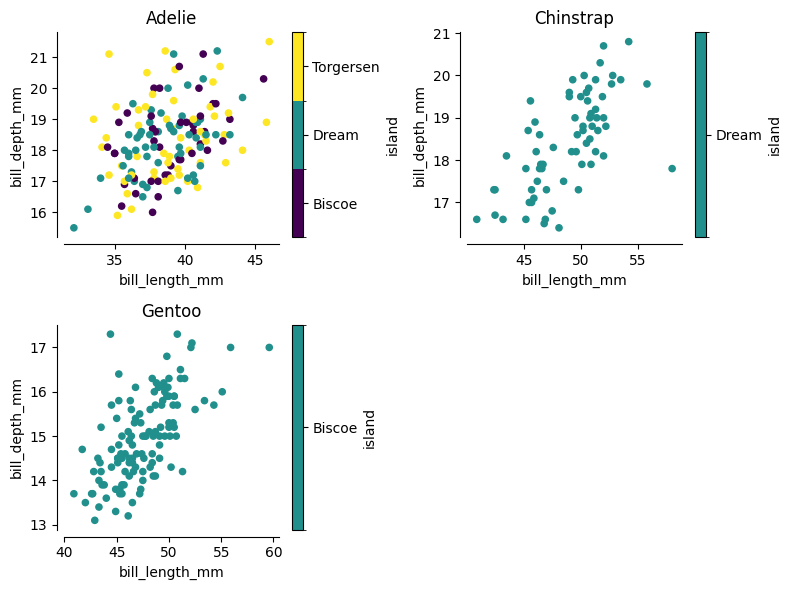

In [134]:
penguins = pt.sample_data['penguins']

# 3 species in a 2-column grid -> 2 rows, 4th cell left blank (not an empty axis)
f = pt.Plotter.facet(
    penguins, by='species', ncols=2,
    kind='scatter', x='bill_length_mm', y='bill_depth_mm', c='island', cmap='viridis',
    figsize=(8, 6),
)
f.finalize()
print('facet axes:', list(f.axd.keys()))
f.fig

In [135]:
import tempfile, os as _os

# .save() is a thin chainable wrapper around fig.savefig()
out_path = _os.path.join(tempfile.mkdtemp(), 'facet_demo.png')
f.save(out_path, dpi=100)
print('saved:', _os.path.exists(out_path))

saved: True


In [136]:
# supported_kwargs(kind) lists ignored kwargs (warned + dropped) and pytae's own
# control kwargs (never forwarded to pandas.plot()) for a given kind
print('scatter:', pt.Plotter.supported_kwargs('scatter'))
print('hist:', pt.Plotter.supported_kwargs('hist'))
print('kde == density:', pt.Plotter.supported_kwargs('kde') == pt.Plotter.supported_kwargs('density'))

scatter: {'unsupported': ['aggfunc', 'by', 'dropna'], 'pytae_controls': ['aggregate', 'clip_data', 'on', 'print_data', 'secondary_y']}
hist: {'unsupported': ['aggfunc', 'dropna'], 'pytae_controls': ['aggregate', 'by', 'clip_data', 'column', 'on', 'print_data', 'secondary_y', 'x', 'y']}
kde == density: True


blank panel B keeps default matplotlib spines/ticks (style=False)


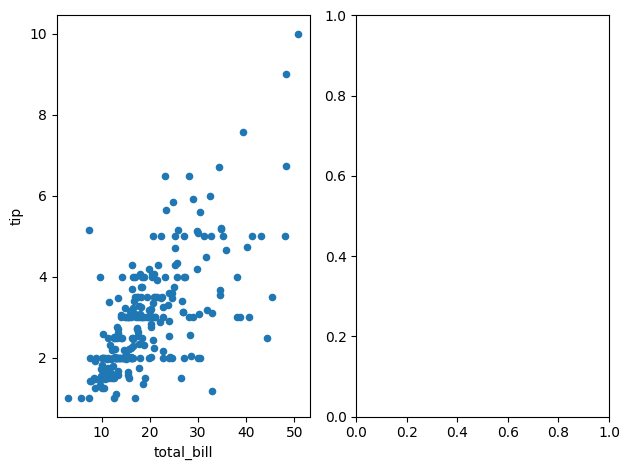

In [137]:
# finalize(style=False) skips pytae's opinionated spine/tick cleanup, leaving a
# blank mosaic panel's matplotlib defaults untouched instead of hiding them
s = pt.Plotter(mosaic='AB').data(tips)
s.plot(kind='scatter', x='total_bill', y='tip', on='A')
s.finalize(style=False)
print('blank panel B keeps default matplotlib spines/ticks (style=False)')
s.fig

In [138]:
# each kind validates its own required kwargs up front -- a clear error instead
# of a cryptic pandas KeyError surfacing later from inside pivoting
try:
    pt.Plotter().data(tips).plot(kind='pie', y='tip')  # missing by=
except ValueError as e:
    print('ValueError:', e)

ValueError: Plotter: kind='pie' needs by=


## Plot kind cookbook — one clean example per kind

Every kind `pandas.plot()` supports works through `.plot(kind=...)`. Each example below uses a different bundled sample dataset for variety.

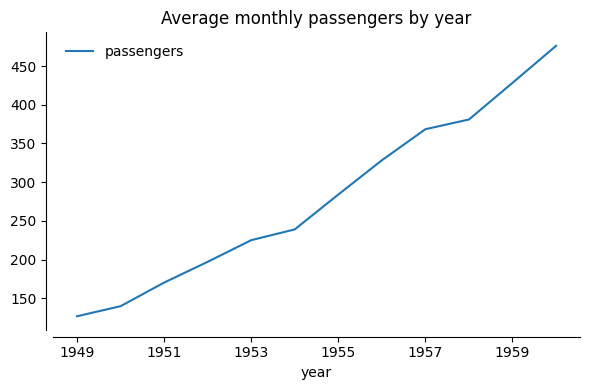

In [139]:
flights = pt.sample_data['flights']

k = pt.Plotter(figsize=(6, 4))
(k
 .data(flights)
 .plot(kind='line', x='year', y='passengers', aggfunc='mean', title='Average monthly passengers by year')
 .finalize()
)
k.fig

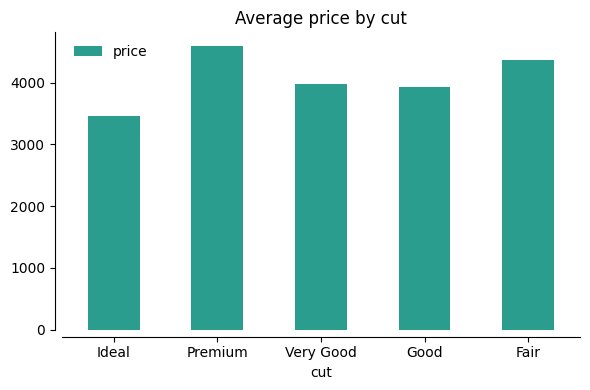

In [140]:
diamonds = pt.sample_data['diamonds']
# diamonds['cut'] is a category dtype -- bars render in its defined order (Ideal..Fair), not alphabetically
colors = ['#2a9d8f', '#e9c46a', '#f4a261', '#e76f51', '#264653']

k = pt.Plotter(figsize=(6, 4))
(k
 .data(diamonds)
 .plot(kind='bar', x='cut', y='price', aggfunc='mean', color=colors, title='Average price by cut')
 .finalize()
)
k.fig

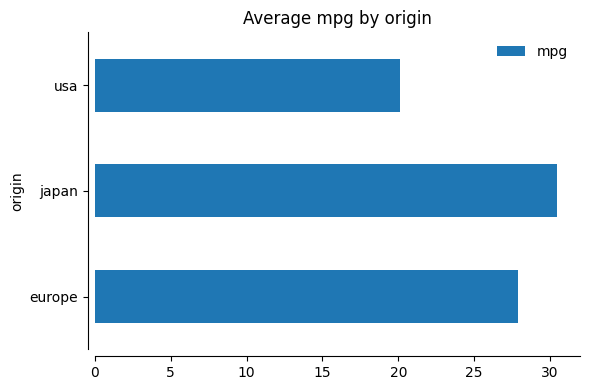

In [141]:
mpg = pt.sample_data['mpg']

k = pt.Plotter(figsize=(6, 4))
(k
 .data(mpg)
 .plot(kind='barh', x='origin', y='mpg', aggfunc='mean', title='Average mpg by origin')
 .finalize()
)
k.fig

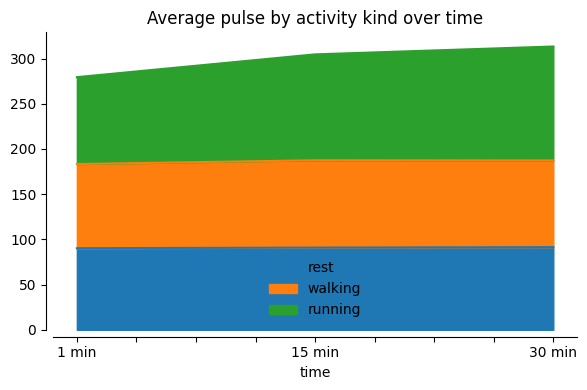

In [142]:
exercise = pt.sample_data['exercise']

k = pt.Plotter(figsize=(6, 4))
(k
 .data(exercise)
 .plot(kind='area', x='time', y='pulse', by='kind', aggfunc='mean', title='Average pulse by activity kind over time')
 .finalize()
)
k.fig

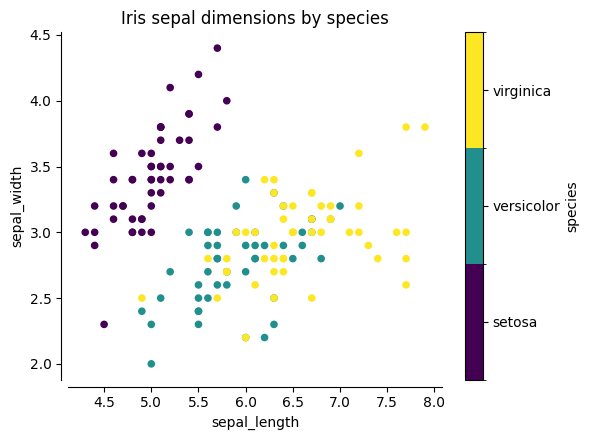

In [143]:
iris = pt.sample_data['iris']

k = pt.Plotter(figsize=(6, 4.5))
(k
 .data(iris)
 .plot(kind='scatter', x='sepal_length', y='sepal_width', c='species', cmap='viridis', title='Iris sepal dimensions by species')
 .finalize()
)
k.fig

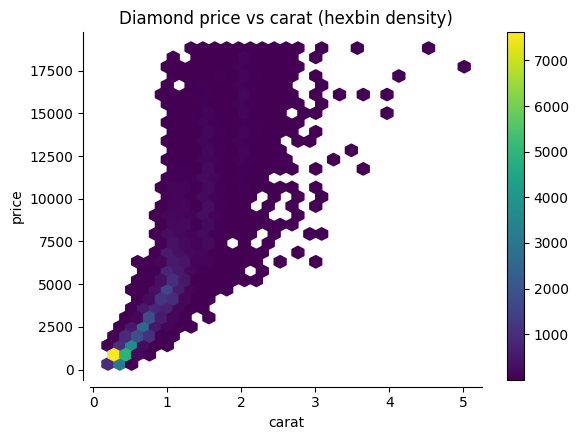

In [144]:
k = pt.Plotter(figsize=(6, 4.5))
(k
 .data(diamonds)
 .plot(kind='hexbin', x='carat', y='price', gridsize=30, cmap='viridis', mincnt=1, title='Diamond price vs carat (hexbin density)')
 .finalize()
)
k.fig

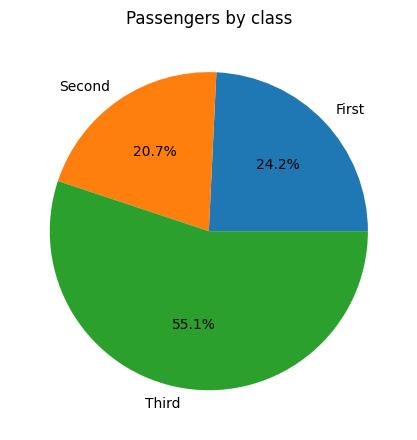

In [145]:
titanic = pt.sample_data['titanic']
titanic_counts = titanic.assign(count=1)  # pie needs a value column to sum; 'count' gives passenger counts per class

k = pt.Plotter(figsize=(4.5, 4.5))
(k
 .data(titanic_counts)
 .plot(kind='pie', y='count', by='class', aggfunc='sum', autopct='%1.1f%%', title='Passengers by class')
 .finalize()
)
k.fig

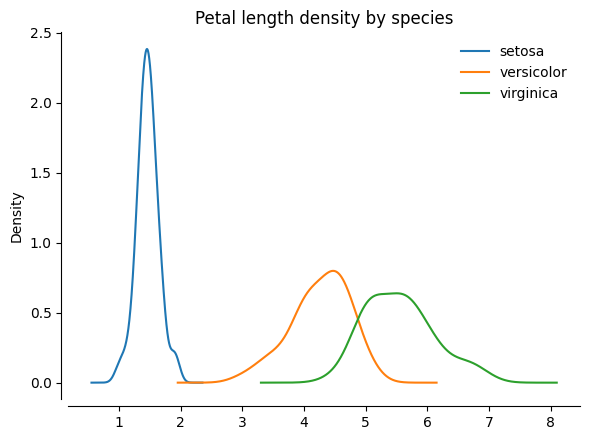

In [146]:
k = pt.Plotter(figsize=(6, 4.5))
(k
 .data(iris)
 .plot(kind='kde', column='petal_length', by='species', title='Petal length density by species')
 .finalize()
)
k.fig

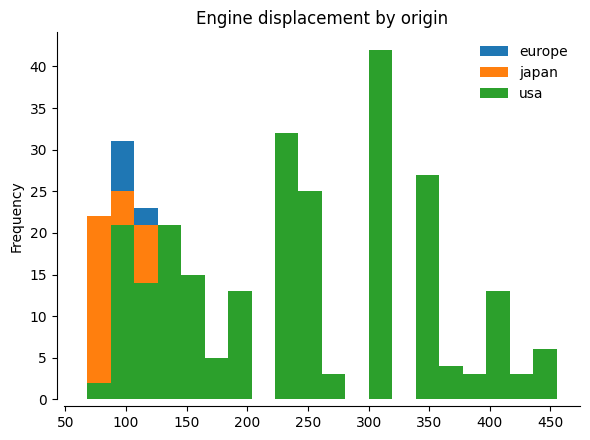

In [147]:
k = pt.Plotter(figsize=(6, 4.5))
(k
 .data(mpg)
 .plot(kind='hist', column='displacement', by='origin', bins=20, title='Engine displacement by origin')
 .finalize()
)
k.fig

## `aggregate=False` and `dropna` controls

`aggregate=False` skips the internal `pivot_table()` aggregation for `line`/`bar`/`barh`/`area` — use it when your data is already one row per `x`/`by` combination. It raises a clear error if that's not actually true. `dropna=` (passed straight through to `pivot_table()`) controls whether rows/columns that are entirely `NaN` after aggregation are dropped (default `True`) or kept.

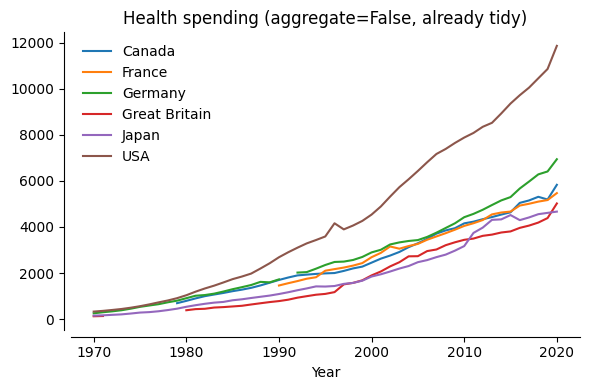

In [148]:
healthexp = pt.sample_data['healthexp']

# healthexp already has exactly one row per Year/Country -- aggregate=False skips the pivot_table() step entirely
k = pt.Plotter(figsize=(6, 4))
(k
 .data(healthexp)
 .plot(kind='line', x='Year', y='Spending_USD', by='Country', aggregate=False, title='Health spending (aggregate=False, already tidy)')
 .finalize()
)
k.fig

In [149]:
tips = pt.sample_data['tips']

# tips has multiple rows per day/sex combination -- aggregate=False can't pivot that without losing data
try:
    pt.Plotter().data(tips).plot(kind='bar', x='day', y='total_bill', by='sex', aggregate=False)
except ValueError as e:
    print('ValueError:', e)

ValueError: Duplicates found in data for pivot. Use aggregate=True or remove duplicates.


In [150]:
tiny = pd.DataFrame({'x': ['a', 'a', 'b', 'b'], 'g': ['p', 'q', 'p', 'q'], 'v': [1.0, np.nan, np.nan, np.nan]})

print('dropna=True (default) -- rows/columns that are entirely NaN after aggregation are dropped:')
pt.Plotter().data(tiny).plot(kind='bar', x='x', y='v', by='g', aggfunc='mean', dropna=True, print_data=True)

print('\ndropna=False -- kept as NaN instead:')
pt.Plotter().data(tiny).plot(kind='bar', x='x', y='v', by='g', aggfunc='mean', dropna=False, print_data=True)

dropna=True (default) -- rows/columns that are entirely NaN after aggregation are dropped:
   x    p
0  a  1.0

dropna=False -- kept as NaN instead:
   x    p   q
0  a  1.0 NaN
1  b  NaN NaN


## Faceting variations: `sort=False`, category dtype order, `titles=False`

By default, facet groups are alphabetically sorted (`sort=True`); `sort=False` keeps first-appearance order instead. A `category`-dtype `by=` column always keeps its own defined category order regardless of `sort=`. `titles=False` skips the per-facet title.

In [151]:
f_sorted = pt.Plotter.facet(titanic, by='embark_town', kind='hist', column='age', figsize=(9, 3))
print('sort=True (default):', list(f_sorted.axd.keys()))

f_unsorted = pt.Plotter.facet(titanic, by='embark_town', sort=False, kind='hist', column='age', figsize=(9, 3))
print('sort=False (first-appearance order):', list(f_unsorted.axd.keys()))

sort=True (default): ['Cherbourg', 'Queenstown', 'Southampton']
sort=False (first-appearance order): ['Southampton', 'Cherbourg', 'Queenstown']


facet panel order follows the category order, not alphabetical: ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']


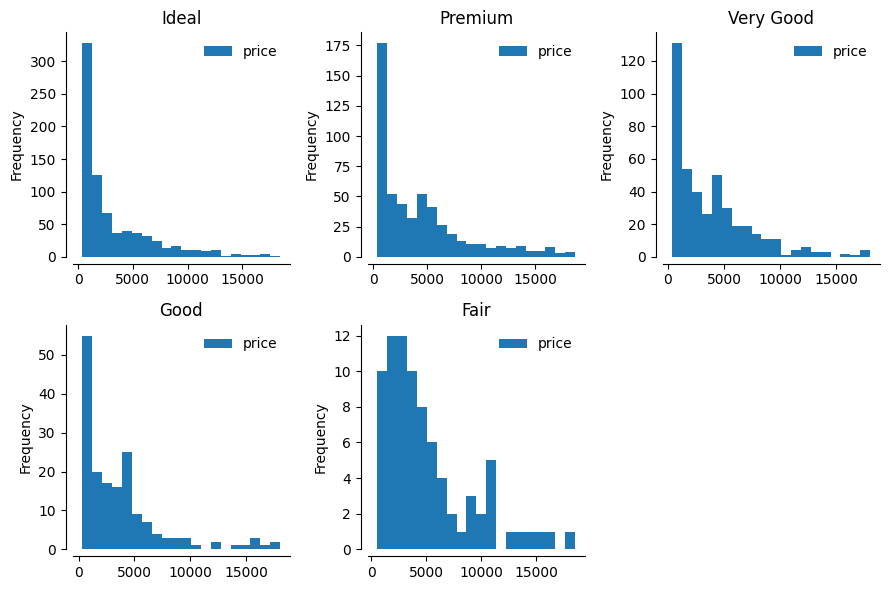

In [152]:
# diamonds['cut'] is a category dtype with a deliberately non-alphabetical order (Ideal is "best", listed first)
f = pt.Plotter.facet(diamonds.sample(2000, random_state=0), by='cut', ncols=3, kind='hist', column='price', bins=20, figsize=(9, 6))
print('facet panel order follows the category order, not alphabetical:', list(f.axd.keys()))
f.finalize()
f.fig

axis title with titles=False: ''


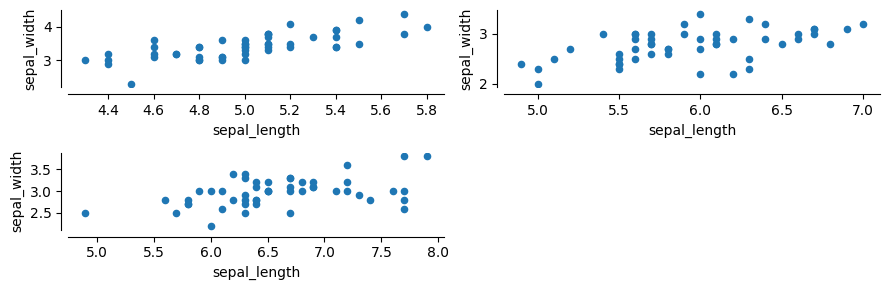

In [153]:
f = pt.Plotter.facet(iris, by='species', titles=False, kind='scatter', x='sepal_length', y='sepal_width', figsize=(9, 3))
f.finalize()
print("axis title with titles=False:", repr(f.axd['setosa'].get_title()))
f.fig

## Per-axis legends: `legend_primary`/`legend_secondary`/`legend_loc`/`legend_frameon`

With `consolidate_legends=False` (the default), each panel keeps its own legend — `legend_primary`/`legend_secondary` toggle it per axis type (primary vs. secondary `^` axes), and `legend_loc`/`legend_frameon` control its placement/frame.

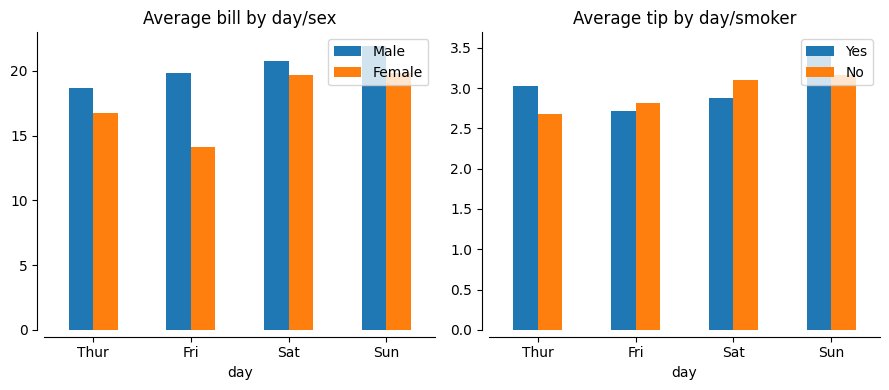

In [154]:
k = pt.Plotter(mosaic='AB', figsize=(9, 4))
(k
 .data(tips)
 .plot(kind='bar', x='day', y='total_bill', by='sex', aggfunc='mean', on='A', title='Average bill by day/sex')
 .plot(kind='bar', x='day', y='tip', by='smoker', aggfunc='mean', on='B', title='Average tip by day/smoker')
 .finalize(consolidate_legends=False, legend_primary=True, legend_secondary=True, legend_loc='upper right', legend_frameon=True)
)
k.fig

## Enhancing a plot after `finalize()` — looping over `axd`/`fig.axes`

Once `.finalize()` has run, `k.axd`/`k.fig.axes` are plain matplotlib `Axes` — loop over them to apply any tweak `Plotter` doesn't expose directly.

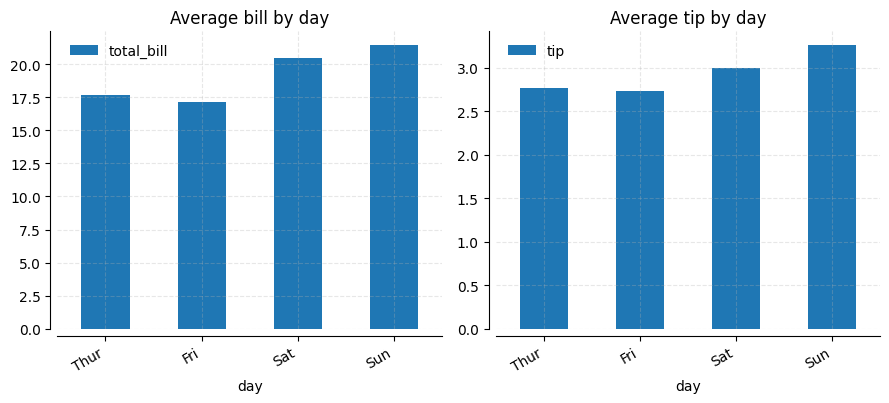

In [155]:
k = pt.Plotter(mosaic='AB', figsize=(9, 4))
(k
 .data(tips)
 .plot(kind='bar', x='day', y='total_bill', aggfunc='mean', on='A', title='Average bill by day')
 .plot(kind='bar', x='day', y='tip', aggfunc='mean', on='B', title='Average tip by day')
 .finalize()
)
for ax_key, ax in k.axd.items():
    ax.grid(True, alpha=0.3, linestyle='--')
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')
k.fig

## Mosaic layouts as a list-of-lists (not just a string)

`mosaic=` is passed straight through to `plt.subplot_mosaic()`, so a nested list of axis keys (letting one panel span multiple grid cells) works just as well as a mosaic string.

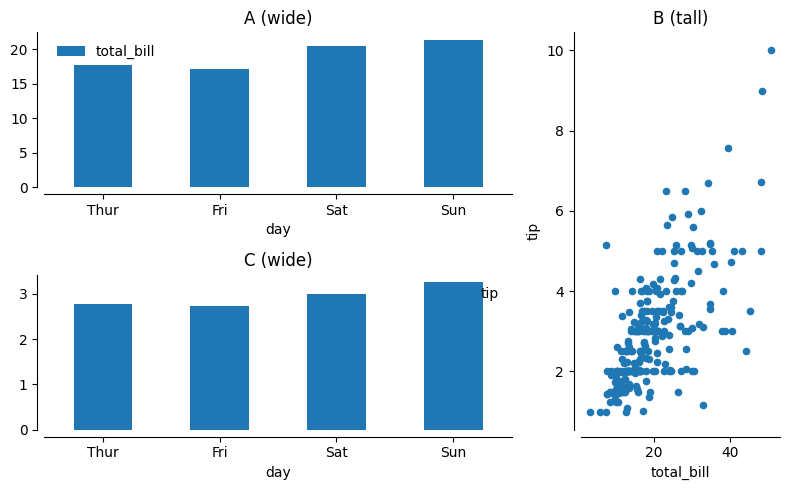

In [156]:
k = pt.Plotter(mosaic=[['A', 'A', 'B'], ['C', 'C', 'B']], figsize=(8, 5))
(k
 .data(tips)
 .plot(kind='bar', x='day', y='total_bill', aggfunc='mean', on='A', title='A (wide)')
 .plot(kind='scatter', x='total_bill', y='tip', on='B', title='B (tall)')
 .plot(kind='bar', x='day', y='tip', aggfunc='mean', on='C', title='C (wide)')
 .finalize()
)
k.fig

## Error handling cookbook

A few more of `Plotter`'s guardrails: missing required kwargs, an unsupported kwarg for a given kind (warned, not silently applied), and an unknown mosaic `on=` key.

In [157]:
import warnings

for kind, kwargs in [('scatter', {'x': 'total_bill'}), ('hist', {})]:
    try:
        pt.Plotter().data(tips).plot(kind=kind, **kwargs)
    except ValueError as e:
        print(f"kind='{kind}':", e)

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    pt.Plotter().data(tips).plot(kind='scatter', x='total_bill', y='tip', aggfunc='mean')  # aggfunc isn't supported for scatter
    print('warning:', w[0].message)

try:
    pt.Plotter().data(tips).plot(kind='bar', x='day', y='total_bill', on='Z')  # 'Z' isn't a mosaic panel
except ValueError as e:
    print('unknown mosaic key:', e)

kind='scatter': Plotter: kind='scatter' needs y=
kind='hist': Plotter: kind='hist' needs column=
unknown mosaic key: Unknown mosaic key 'Z'; available: ['A']


## Post-plot manipulation patterns (from real-world dashboards)

`Plotter` covers the common case, but `k.fig`/`k.axd` are plain matplotlib objects underneath — real dashboards lean on that for things `Plotter` doesn't expose directly: custom tick formatting, per-axis-type y-limits, reference lines that still show up in the consolidated legend, hand-drawn chart types, and frame-by-frame animation. Dummy data below.

In [158]:
from matplotlib.ticker import FuncFormatter

rng = np.random.default_rng(42)
dates = pd.date_range('2021-03-31', periods=8, freq='QE').astype(str)
banks = ['Alpha', 'Beta', 'Gamma']
stages = ['Stage 1', 'Stage 2', 'Stage 3']

rows = []
for d in dates:
    for b in banks:
        exposure = rng.uniform(80, 120)
        for s in stages:
            rows.append({'date': d, 'bank': b, 'stage': s,
                         'ecl': rng.uniform(1, 5) * {'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 4}[s],
                         'exposure': exposure})
ecl = pd.DataFrame(rows)
coverage = (ecl.groupby(['date', 'bank'], as_index=False)
            .agg(ecl=('ecl', 'sum'), exposure=('exposure', 'first'))
            .assign(coverage_pct=lambda x: x['ecl'] / x['exposure'] * 100))
ecl.head()

,date,bank,stage,ecl,exposure
0,2021-03-31,Alpha,Stage 1,2.755514,110.958242
1,2021-03-31,Alpha,Stage 2,8.868783,110.958242
2,2021-03-31,Alpha,Stage 3,15.157888,110.958242
3,2021-03-31,Beta,Stage 1,4.902489,83.767094
4,2021-03-31,Beta,Stage 2,8.089118,83.767094


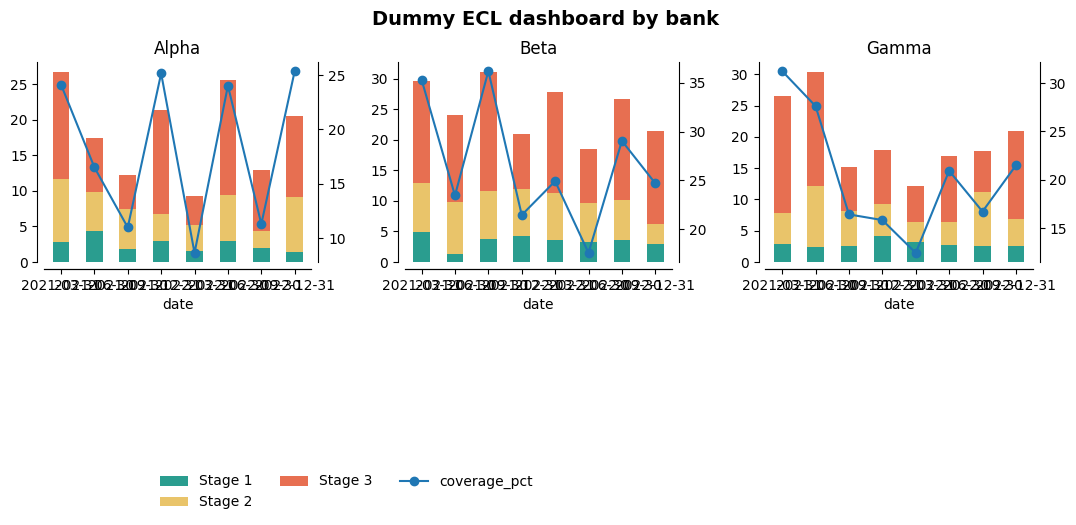

In [159]:
# build a mosaic dashboard by looping over groups instead of chaining each panel by hand
stage_colors = {'Stage 1': '#2a9d8f', 'Stage 2': '#e9c46a', 'Stage 3': '#e76f51'}
k = pt.Plotter(mosaic='ABC', figsize=(11, 4))
for bank, ax_key in zip(banks, ['A', 'B', 'C']):
    (k
     .data(ecl[ecl['bank'] == bank])
     .plot(x='date', y='ecl', by='stage', kind='bar', stacked=True, on=ax_key, title=bank, color=stage_colors)
     .data(coverage[coverage['bank'] == bank])
     .plot(x='date', y='coverage_pct', kind='line', on=f'{ax_key}^', color='black', marker='o')
    )
k.finalize(consolidate_legends=True, bbox_to_anchor=(0.5, -0.15), ncols=3)
k.fig.suptitle('Dummy ECL dashboard by bank', fontsize=14, fontweight='bold')
k.fig.subplots_adjust(top=0.85, bottom=0.35, wspace=0.35)
k.fig

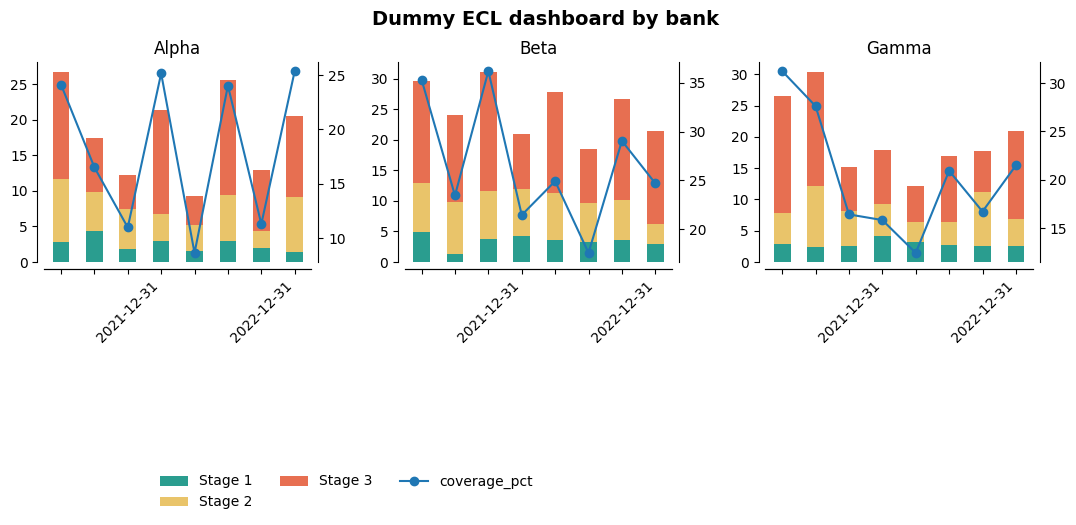

In [160]:
# custom tick relabeling -- e.g. only label Q4, blank out the rest, rotated
all_dates = ecl['date'].unique()
q_labels = [d if d.endswith('12-31') else '' for d in all_dates]
for ax in k.fig.axes:
    ax.set_xticks(range(len(all_dates)))
    ax.set_xticklabels(q_labels, rotation=45, ha='right')
    ax.set_xlabel('')
k.fig

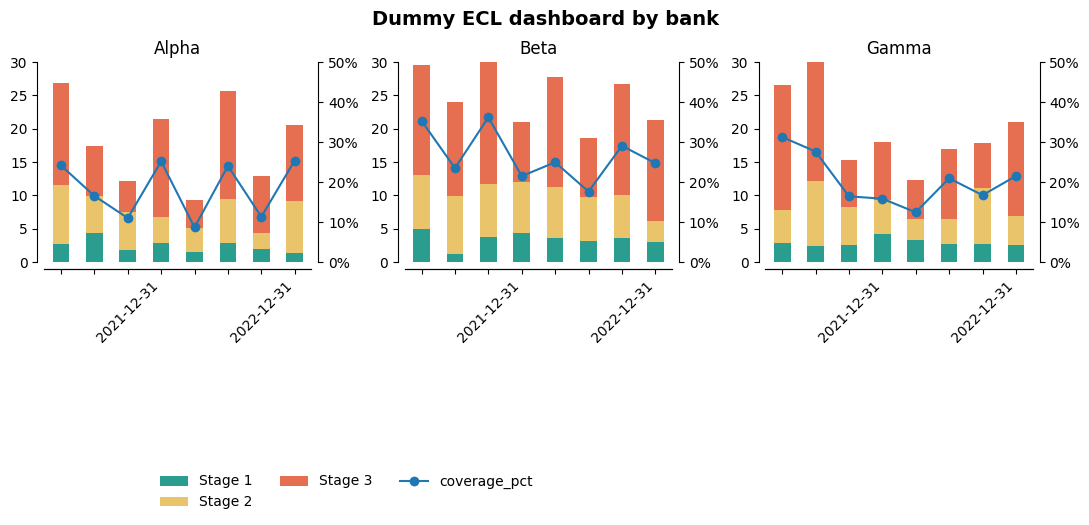

In [161]:
# per-axis-type y-limits (primary vs secondary '^') + a percent formatter on the secondary axes
for ax_key, ax in k.axd.items():
    if ax_key.endswith('^'):
        ax.set_ylim(0, 50)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
    else:
        ax.set_ylim(0, 30)
k.fig

### Reference lines drawn before `.plot()`/`.finalize()` — still show up in the consolidated legend

Grab an axis straight from `k.axd[...]` and call matplotlib directly (`axhline`, `axvline`, `axvspan`, ...) *before* chaining `.plot()`/`.finalize()`. As long as the line has a `label=`, `finalize(consolidate_legends=True)` picks it up along with everything plotted afterward.

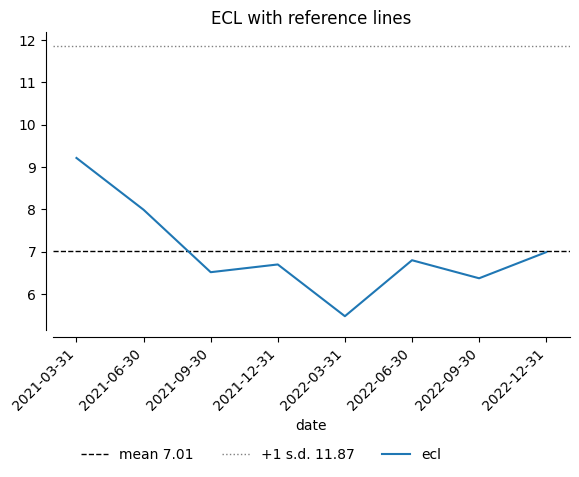

In [162]:
hist_mean = ecl['ecl'].mean()
hist_std = ecl['ecl'].std()

k2 = pt.Plotter(figsize=(6, 4))
k2.axd['A'].axhline(y=hist_mean, color='black', linestyle='--', linewidth=1, label=f'mean {hist_mean:.2f}')
k2.axd['A'].axhline(y=hist_mean + hist_std, color='grey', linestyle=':', linewidth=1, label=f'+1 s.d. {hist_mean + hist_std:.2f}')
(k2
 .data(ecl.groupby('date', as_index=False)['ecl'].mean())
 .plot(x='date', y='ecl', kind='line', on='A', title='ECL with reference lines')
 .finalize(consolidate_legends=True, bbox_to_anchor=(0.75, -0.1))
)
# rotate the date labels so 8 quarterly x-tick strings don't overlap into a jumbled mess
for label in k2.axd['A'].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')
k2.fig

### Relabeling ticks after the fact — mirrored/diverging bars

A diverging bar chart (e.g. inflow vs. outflow) often stores one side as negative purely so `stacked=True` stacks it below zero — the axis itself should still read as a magnitude. Grab the tick positions from the rendered axis and override the tick *text* only, leaving the underlying data/bars untouched.

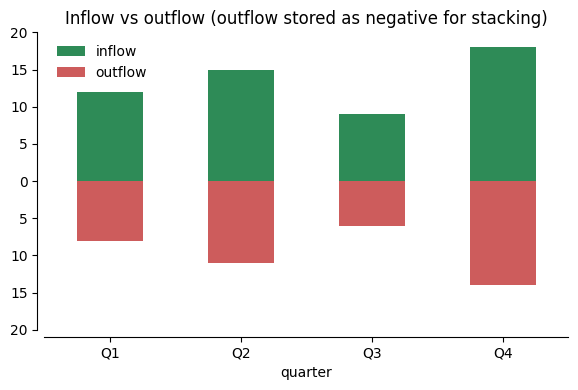

In [163]:
diverge = pd.DataFrame({
    'quarter': ['Q1', 'Q2', 'Q3', 'Q4'] * 2,
    'flow': ['inflow'] * 4 + ['outflow'] * 4,
    'amount': [12, 15, 9, 18, -8, -11, -6, -14],
})
diverge['flow'] = pd.Categorical(diverge['flow'], categories=['inflow', 'outflow'], ordered=True)

k4 = pt.Plotter(figsize=(6, 4))
(k4
 .data(diverge)
 .plot(x='quarter', y='amount', by='flow', kind='bar', stacked=True,
       color={'inflow': 'seagreen', 'outflow': 'indianred'},
       title='Inflow vs outflow (outflow stored as negative for stacking)')
 .finalize()
)

# outflow was only negative to stack below zero -- both sides are magnitudes, so relabel as absolute values
ax = k4.axd['A']
ticks = ax.get_yticks()
ax.set_yticks(ticks)
ax.set_yticklabels([f'{abs(t):.0f}' for t in ticks])
k4.fig

## More matplotlib fine control on top of a `Plotter` chart

`k.axd[...]`/`k.fig` are just matplotlib underneath, so anything matplotlib itself supports keeps working after `.finalize()` — data labels on bars, recoloring a single element, annotations/arrows, shaded regions, and even embedding a fully separate inset `Axes`.

### Data labels on bars — looping over `ax.patches`

Each bar is a matplotlib `Rectangle` in `ax.patches`; read its height/position back and `ax.annotate()`/`ax.text()` a label above it.

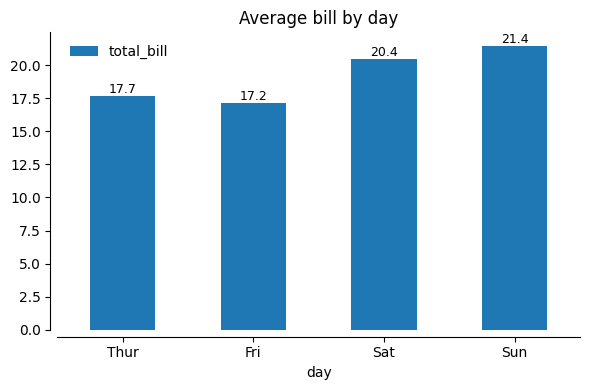

In [164]:
k = pt.Plotter(figsize=(6, 4))
(k
 .data(tips)
 .plot(x='day', y='total_bill', kind='bar', aggfunc='mean', title='Average bill by day', legend=False)
 .finalize()
)
ax = k.axd['A']
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'{height:.1f}', (patch.get_x() + patch.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9)
k.fig

### Highlighting a single bar — restyling one element after the fact

`ax.patches` is ordered the same as the plotted x-categories, so match a category by its tick label position, then restyle just that one `Rectangle`.

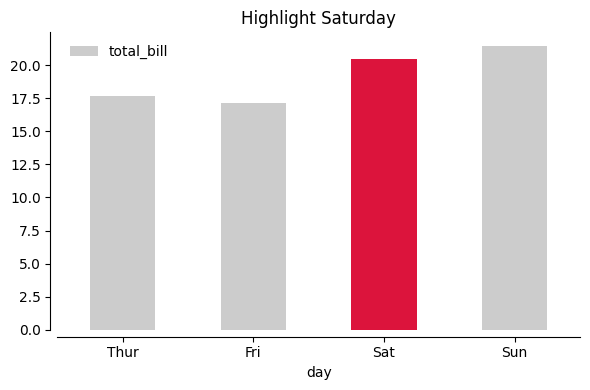

In [165]:
k2 = pt.Plotter(figsize=(6, 4))
(k2
 .data(tips)
 .plot(x='day', y='total_bill', kind='bar', aggfunc='mean', color='#cccccc', title='Highlight Saturday', legend=False)
 .finalize()
)
ax2 = k2.axd['A']
day_order = [t.get_text() for t in ax2.get_xticklabels()]
ax2.patches[day_order.index('Sat')].set_facecolor('crimson')
k2.fig

### Shaded regions and arrow annotations

`ax.axvspan()`/`ax.axhspan()` shade a region; `ax.annotate(..., arrowprops=...)` points an arrow at a specific data point (e.g. a peak).

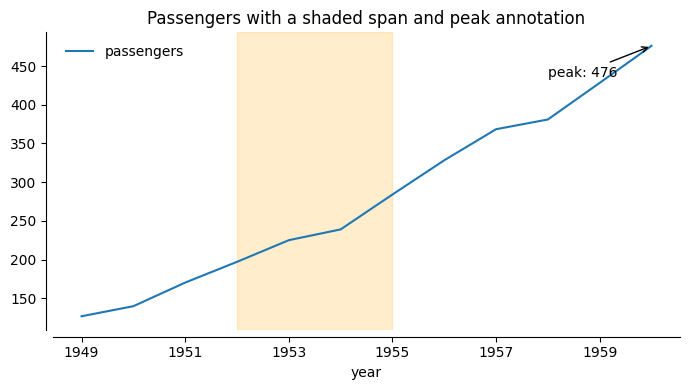

In [166]:
k3 = pt.Plotter(figsize=(7, 4))
(k3
 .data(flights)
 .plot(x='year', y='passengers', kind='line', aggfunc='mean', title='Passengers with a shaded span and peak annotation', legend=False)
 .finalize()
)
ax3 = k3.axd['A']
ax3.axvspan(3, 6, color='orange', alpha=0.2)

series = flights.groupby('year')['passengers'].mean()
years_sorted = sorted(flights['year'].unique())
peak_year = series.idxmax()
peak_x = years_sorted.index(peak_year)
ax3.annotate(f'peak: {series.max():.0f}', xy=(peak_x, series.max()), xytext=(peak_x - 2, series.max() - 40),
             arrowprops=dict(arrowstyle='->', color='black'))
k3.fig

### Embedding a fully separate inset `Axes` for a zoomed-in view

`ax.inset_axes()` creates a brand-new matplotlib `Axes` inside an existing pytae panel — plot into it with plain matplotlib, then `ax.indicate_inset_zoom()` draws the connector box.

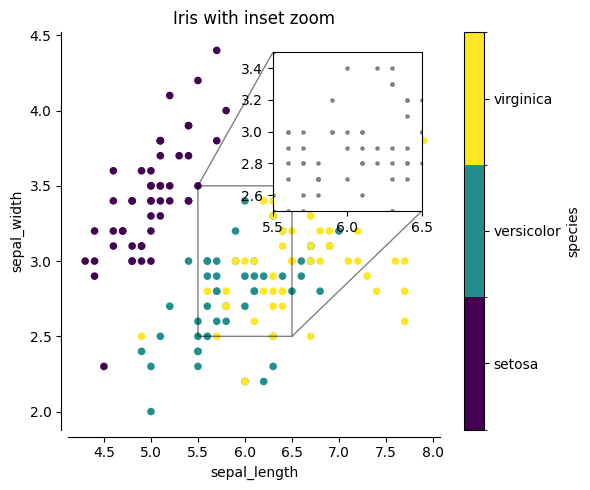

In [167]:
k4 = pt.Plotter(figsize=(6, 5))
(k4
 .data(iris)
 .plot(kind='scatter', x='sepal_length', y='sepal_width', c='species', cmap='viridis', title='Iris with inset zoom')
 .finalize()
)
ax4 = k4.axd['A']
axins = ax4.inset_axes([0.55, 0.55, 0.4, 0.4])
axins.scatter(iris['sepal_length'], iris['sepal_width'], s=5, c='grey')
axins.set_xlim(5.5, 6.5)
axins.set_ylim(2.5, 3.5)
ax4.indicate_inset_zoom(axins, edgecolor='black')
k4.fig